<h1><b>Mission client : Analyse émotionnelle de texte simple</b></h1>
<h3>Contexte :</h3>
<p><i>Je suis un auteur indépendant qui souhaite mieux comprendre les émotions véhiculées dans mes dialogues et extraits narratifs. J’ai besoin d’un outil simple capable d’analyser des phrases courtes et de me dire si elles expriment plutôt de la tristesse, de la colère, de la joie, de la surprise ou de la peur.</i></p>

<h4>Objectif de la mission</h4>
<ul><p>Créer un programme capable de :</p>

<li>Prendre en entrée une phrase courte (1 à 2 lignes maximum).</li>
<li>Détecter l’émotion dominante parmi 4 catégories : tristesse, colère, joie, peur, surprise.</li>
<li>Afficher le résultat de manière lisible (console, fichier texte ou interface simple).</li></ul>
<ul>
<p>Livrables attendus:</p>
<li>Un script Python fonctionnel (idéalement Jupyter Notebook ou fichier .py).</li>
<li>Une documentation simple expliquant : - Comment utiliser le programme. -Comment il fonctionne (même brièvement).</li>
<li>Un exemple de test avec 10 phrases et les émotions détectées.</li>
</ul>
<ul>
<p>Contraintes et périmètre: </p>
<li>Type de texte : phrases courtes uniquement (pas de paragraphes).</li>
<li>Format d’entrée : texte brut ou fichier .txt.</li>
</ul>

In [1]:
#Importation des librairies
import numpy as np
import pandas as pd
from collections import Counter
import re
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Importation des données
url_emotion_txt_df = r"../Datasets/EmotionTexteDataset/emotions.csv"
url_sentiment_df = r"../Datasets/SentimentDataset/training.1600000.processed.noemoticon.csv"

In [3]:
#Lecture des deux Dataframes
df_emotion_txt = pd.read_csv(url_emotion_txt_df)
df_sentiment = pd.read_csv(url_sentiment_df, encoding = "latin-1")

<h2>Annalyse exploratoire des données (AED)</h2>

In [4]:
#On affiche la dimension des données
df_emotion_txt.shape

(416809, 2)

In [5]:
#On affiche les types de données
df_emotion_txt.dtypes

text     object
label     int64
dtype: object

In [6]:
#On regarde si il y a des doublons
df_emotion_txt[df_emotion_txt.duplicated()]

,text,label
8397,i told my staff i said you know i feel invigor...,1
15187,i feel fine,1
15638,i feel bob loblaw is a handsome professional m...,1
19413,i feel tortured var fb comment action link hre...,3
23711,i also have no particular feeling of patriotis...,2
...,...,...
415504,i am a sentimental woman n extremely sensitive...,2
415867,i just screend up your profile and i feel you ...,1
415891,the death of my father,0
416310,i feel so innocent,1


In [7]:
df_emotion_txt.duplicated().sum()

686

In [8]:
#On affiche si il y a des valeurs manquantes
df_emotion_txt.isna().sum()

text     0
label    0
dtype: int64

In [9]:
df_emotion_txt[df_emotion_txt["text"].isna()]

,text,label


In [10]:
#On affiche infos détailler des données
df_emotion_txt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    416809 non-null  object
 1   label   416809 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 6.4+ MB


<h4>Récapitulatif des premières informations du DataFrame</h4>
<ul>
    <li>Il est constitué de 416_809 lignes et de 2 colonnes</li>
    <li>Deux types seulement dans nos données. Objet pour text et Int pour les labels</li>
    <li>On constate qu'il y a des doublons. C'est-à-dire 686 phrases apparaissent plusieurs fois de manière identique. Donc, un risque d'overfitting qui entraînera potentiellement un résultat trop confiant. Il faudra donc nettoyer en supprimant les doublons</li>
    <li>Il n'y a pas de valeurs manquantes dans nos données.</li>
</ul>

In [11]:
#Analyse linguistique simple
def get_word(text):
    return re.findall(r"\b\w+\b", text.lower())
all_words = [w for text in df_emotion_txt["text"] for w in get_word(text)]
Counter(all_words).most_common(20)

[('i', 676203),
 ('feel', 289939),
 ('and', 250279),
 ('to', 233106),
 ('the', 216648),
 ('a', 162914),
 ('feeling', 134185),
 ('that', 130733),
 ('of', 129993),
 ('my', 111199),
 ('in', 86434),
 ('it', 84465),
 ('like', 73972),
 ('so', 65014),
 ('for', 64050),
 ('im', 61662),
 ('have', 61334),
 ('me', 60494),
 ('but', 58592),
 ('was', 57557)]

In [12]:
#Classement des label
tristesse = (df_emotion_txt["label"] == 0).sum()
joie = (df_emotion_txt["label"] == 1).sum()
amour = (df_emotion_txt["label"] == 2).sum()
colere = (df_emotion_txt["label"] == 3).sum()
peur =(df_emotion_txt["label"] == 4).sum()
surprise = (df_emotion_txt["label"] == 5).sum()

print("1 - Joie: ", joie)
print("0 - Tristesse: ", tristesse)
print("2 - Amour: ", amour)
print("3 - Colere: ", colere)
print("4 - Peur: ", peur)
print("5 - Surprise: ", surprise)
print("\n")

df_emotion_txt["label"].value_counts(normalize = True)

1 - Joie:  141067
0 - Tristesse:  121187
2 - Amour:  34554
3 - Colere:  57317
4 - Peur:  47712
5 - Surprise:  14972




label
1    0.338445
0    0.290749
3    0.137514
4    0.114470
2    0.082901
5    0.035921
Name: proportion, dtype: float64

In [13]:
#Voir si il y a des majuscules dans nos textes
print(f"Nombre de majuscule : {df_emotion_txt["text"].str.isupper().sum()}")

Nombre de majuscule : 0


<p>Théoriquement un texte est considéré comme trop court s'il est moins de 5 caractères. (Faut les supprimer). Entre 5 à 10 caractères.(Parfois utiles mais à voir). Un texte normal doit dépasser les 10 caractères. Et au-dessus de 20 mots. C'est très riche et bon pour un modèle ML. On va analyser manuellement ceux entre 5 et 10.</p>

In [14]:
print(f"Texte en majuscule: {df_emotion_txt["text"].str.isupper().value_counts()}")
print("\n")
print(f"Texte en minuscule: {df_emotion_txt["text"].str.islower().value_counts()}")

Texte en majuscule: text
False    416809
Name: count, dtype: int64


Texte en minuscule: text
True    416809
Name: count, dtype: int64


In [15]:
#Afficher si il y a des caractère spéciaux
mask = df_emotion_txt.apply(lambda col: col.astype(str).str.contains(r"[^\x00-\x7F]", regex = True))
contains_spec_caract = df_emotion_txt[mask.any(axis = 1)]

print(f"Nombre de caractère spéciaux : {contains_spec_caract}")

Nombre de caractère spéciaux : Empty DataFrame
Columns: [text, label]
Index: []


In [16]:
#Voir si il y a des URL
url_pattern = r"https?://\S+"

mask_url = df_emotion_txt.applymap(lambda x: bool(re.search(url_pattern, str(x))))
df_emotion_txt_url_contains = df_emotion_txt[mask.any(axis = 1)]

print(f"Les URLs contenu dans notre dataset : {df_emotion_txt_url_contains}")

Les URLs contenu dans notre dataset : Empty DataFrame
Columns: [text, label]
Index: []


<h3>Visualisation des données</h3>
<ul>
 <li>Graphique en barres.</li>
 <li>Nuage des mots.</li>
</ul>

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

<Axes: xlabel='label'>

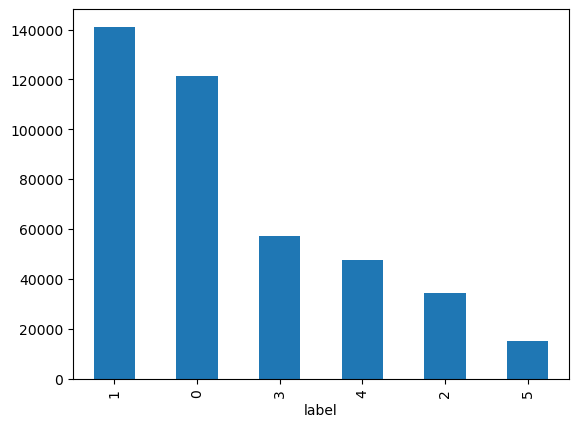

In [18]:
df_emotion_txt["label"].value_counts().plot(kind = "bar")

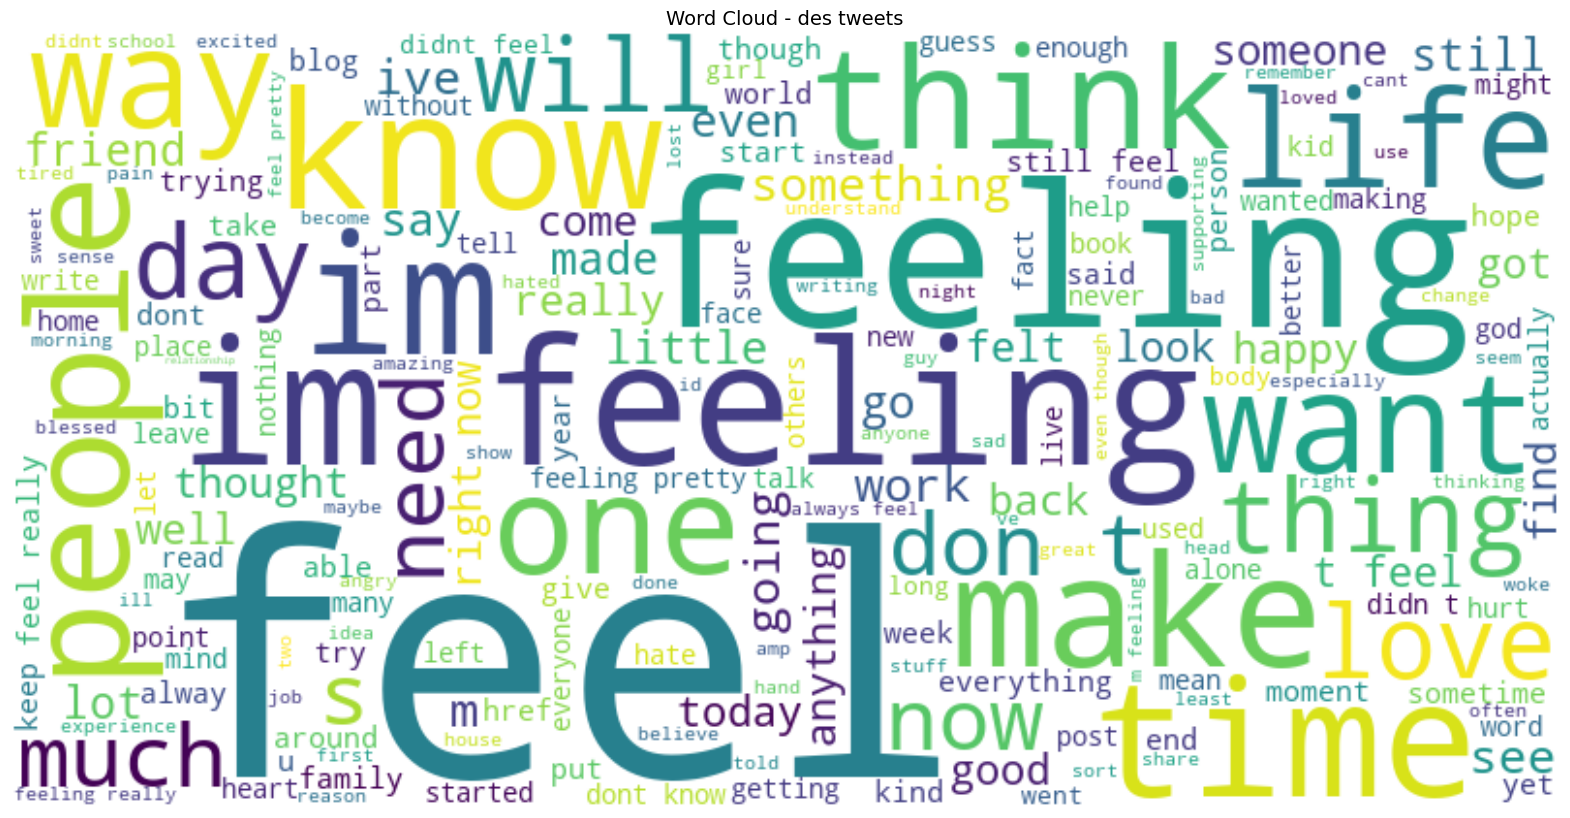

In [19]:
#Création d'une fonction pour générer le WordCloud
#Voir potentiellement ce qui faut néttoyer
def generate_wordcloud(tweets, titre):
    all_text = " ".join(tweets)
    wordcloud = WordCloud(width = 800, height = 400, background_color = "white").generate(all_text)

    plt.figure(figsize = (20, 15))
    plt.imshow(wordcloud, interpolation = "bilinear")
    plt.title(titre, fontsize = 14)
    plt.axis("off")
    plt.show()

#Appel de la fonction
generate_wordcloud(tweets = df_emotion_txt["text"], titre = "Word Cloud - des tweets")

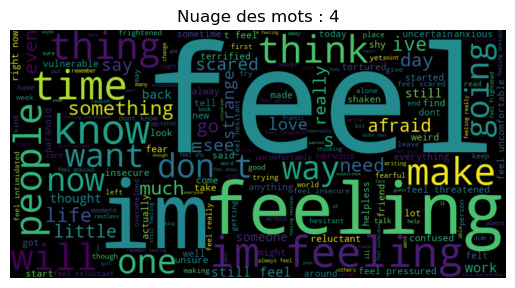

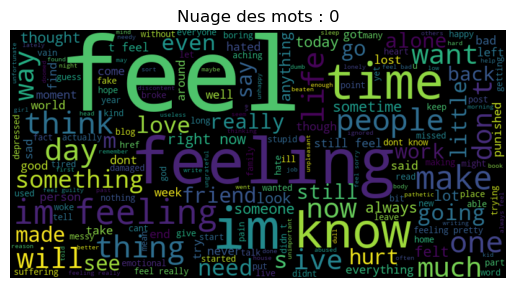

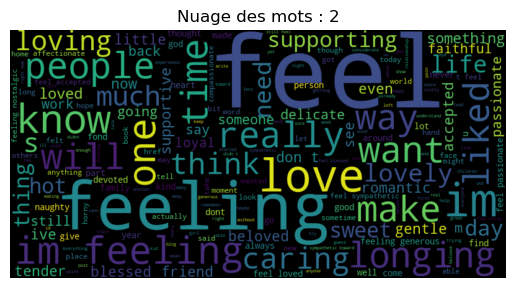

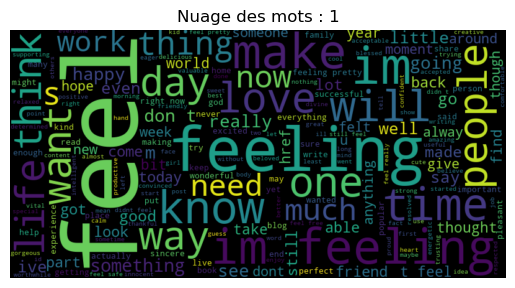

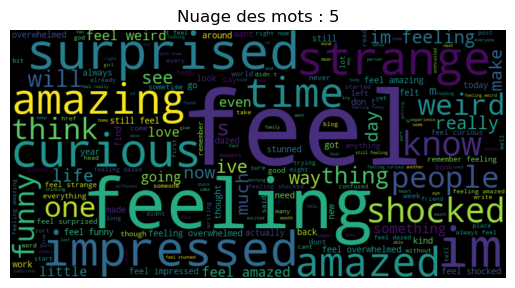

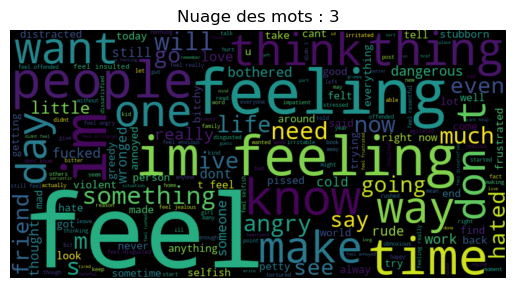

In [20]:
#Affichage des nuages de mots par classe
for emotion in df_emotion_txt["label"].unique():
    text = " ".join(df_emotion_txt[df_emotion_txt["label"] == emotion]["text"])
    wordcloud = WordCloud(width = 800, height = 400).generate(text)

    plt.imshow(wordcloud, interpolation = "bilinear")
    plt.axis("off")
    plt.title(f"Nuage des mots : {emotion}")
    plt.show()

<h4>Récapitulatif de notre AED</h4>
<ul>
    <li>416809 lignes et 2 colonnes.</li>
    <li>686 phrases apparaissent plusieurs fois de manière identique (même texte et label).</li>
    <li>Pas de valeurs manquantes.</li>
    <li>Rappel des Étiquettes : On peut donc constater que la joie est prédominante sur le nombre d'échantillons. Tandis que la classe surprise représente peu d'échantillons.</li>
    <li>"I(676203)" et "feel (289939)" sont les mots qui ressortent le plus.</li>
    <li>Pas de str en majuscule dans le texte. Donc inutile de convertir les données contenues dans texte en lower case.</li>
    <li>as de caractères spéciaux visiblement.</li>
    <li>Pas d'URL à signaler non plus.</li>
</ul>